#**Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  25.6MB/s    in 10s     

2026-08-14 04:47:24 (19.6 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]


#### Install the required libraries and import them


In [2]:
!pip install pandas

In [4]:
!pip install matplotlib

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [7]:
QUERY = "SELECT COUNT(*) FROM main"
df1 = pd.read_sql_query(QUERY, conn)
print(df1)


   COUNT(*)
0     65437

**Demo 2: List all tables**


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


In [ ]:
## Write your code here
df=pd.read_csv('survey-data.csv')
import sqlite3
conn=sqlite3.connect('survey-data.sqlite')
df.to_sql('main',conn,if_exists='replace',index=False)
Query="SELECT * FROM main" 
df=pd.read_sql_query(Query,conn)
Q1 = df["CompTotal"].quantile(0.25)
Q3 = df["CompTotal"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df["CompTotal"] >= lower) & 
    (df["CompTotal"] <= upper)
] 

<Axes: ylabel='Frequency'>

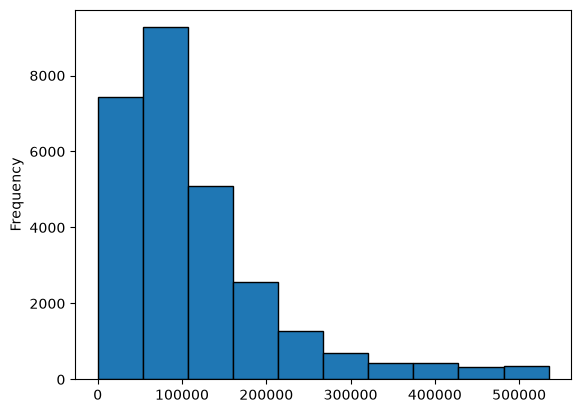

In [38]:
df["CompTotal"].plot.hist(edgecolor='black')

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


In [36]:
## Write your code here
# 1. Convert text to numbers, forcing non-numeric text (like "Less than 1 year") to NaN
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')



<Axes: ylabel='Frequency'>

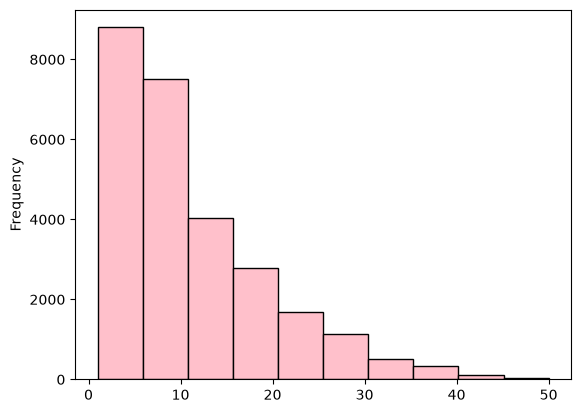

In [39]:
df["YearsCodePro"].plot.hist(edgecolor="black",color="pink")

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


In [43]:
## Write your code here
!pip install seaborn 
import seaborn as sns

<Axes: xlabel='CompTotal', ylabel='Count'>

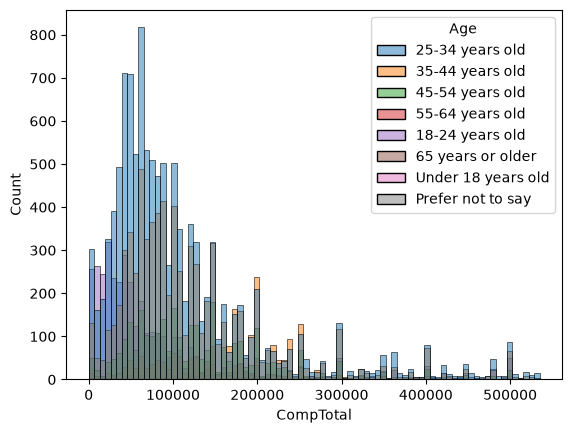

In [45]:
sns.histplot(data=df,x="CompTotal",hue="Age",edgecolor="black")

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


In [ ]:
## Write your code here
# 1. Define the mapping dictionary using the median minutes for each range
time_mapping = {
    'Less than 15 minutes a day': 7.5,    # Midpoint between 0 and 15
    '15-30 minutes a day': 22.5,          # Midpoint between 15 and 30
    '30-60 minutes a day': 45.0,          # Midpoint between 30 and 60
    '60-120 minutes a day': 90.0,         # Midpoint between 60 and 120
    'Over 120 minutes a day': 150.0       # Conservative estimate for "Over 120"
}

# 2. Create a new numeric column using the map
df['TimeSearching'] = df['TimeSearching'].map(time_mapping)

<Axes: xlabel='TimeSearching', ylabel='Count'>

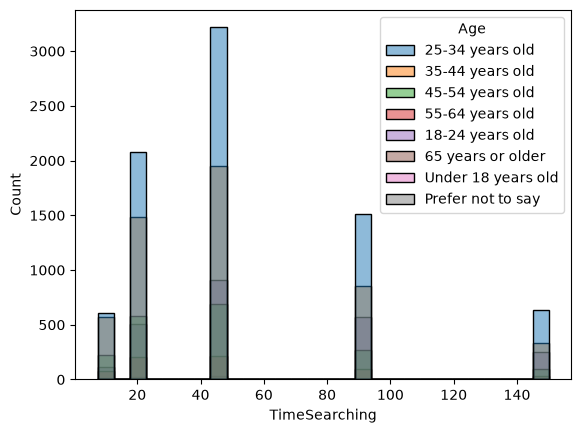

In [49]:
sns.histplot(data=df,x="TimeSearching",hue="Age")

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


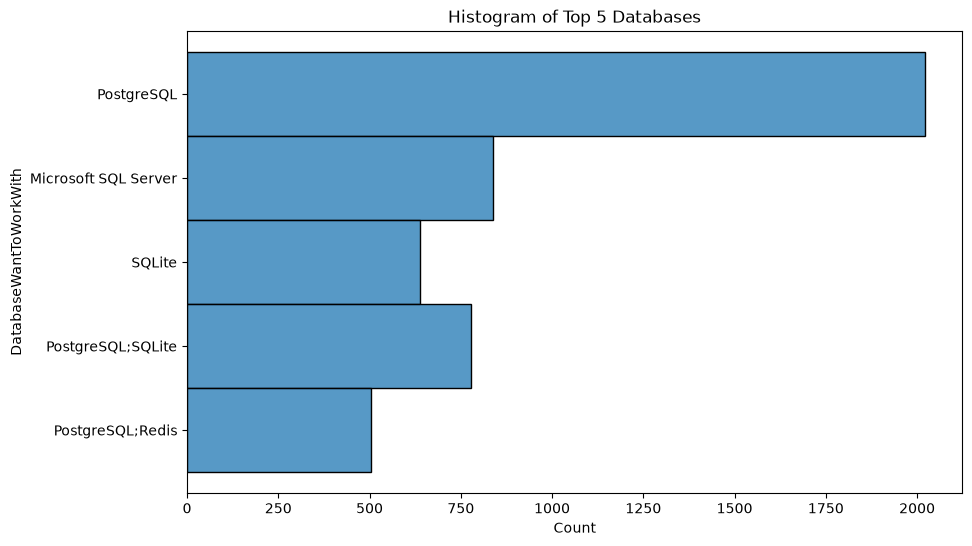

In [59]:
## Write your code here

# 1. Get the names of the top 5 databases
top_5_names = df["DatabaseWantToWorkWith"].value_counts().head().index

# 2. Filter the dataframe to only include those 5 databases
df_top5 = df[df["DatabaseWantToWorkWith"].isin(top_5_names)]

# 3. Create the histogram (putting it on 'y' keeps the names readable!)
plt.figure(figsize=(10, 6))
sns.histplot(data=df_top5, y="DatabaseWantToWorkWith")

plt.title("Histogram of Top 5 Databases")
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


<Axes: xlabel='Count', ylabel='RemoteWork'>

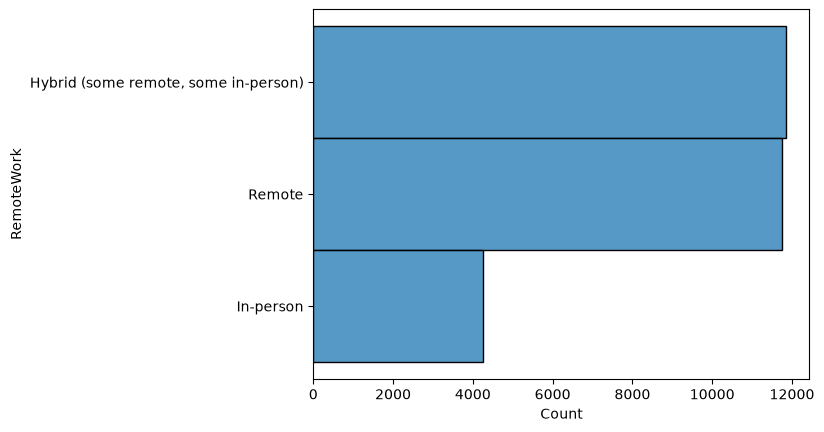

In [63]:
## Write your code here
data=df["RemoteWork"].value_counts()
nm=data.index
count=df[df["RemoteWork"].isin(nm)]
sns.histplot(data=count,y="RemoteWork")

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


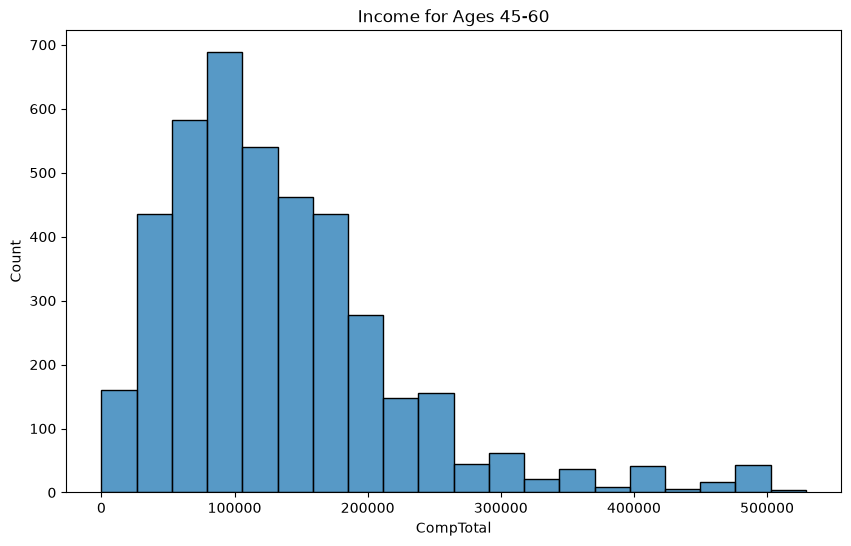

In [65]:
## Write your code here
# Filter for both age groups
ages = [
    "45-54 years old",
    "55-64 years old",
]
col = "Age"
mask = df[col].isin(ages)
df_filtered = df[mask]

# Plot the income distribution
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_filtered,
    x="CompTotal",
    bins=20,
    edgecolor="black",
)
plt.title("Income for Ages 45-60")
plt.show()


**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


<Axes: xlabel='YearsCodePro', ylabel='Count'>

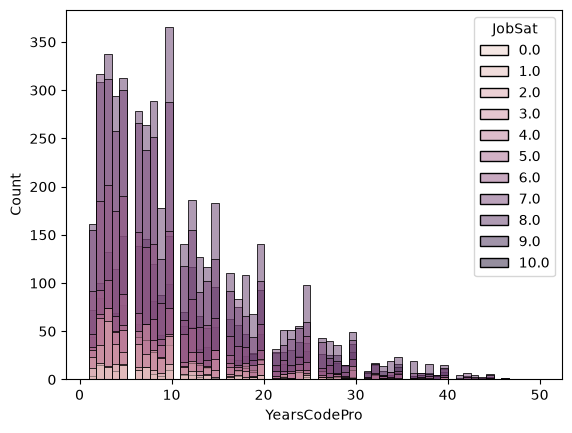

In [73]:
## Write your code here
sns.histplot(data=df,x="YearsCodePro",hue="JobSat")

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [16]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
